In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

scaler= StandardScaler()

data = pd.read_csv("../Dataset/diabetes.csv")

X = data.drop("Outcome", axis = 1).to_numpy()
y = data["Outcome"].to_numpy()

X_scaled= scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=909, stratify= y
)

In [3]:
log_reg= LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)
y_pred= log_reg.predict(X_test)


In [4]:
matrix= confusion_matrix(y_test, y_pred)
matrix

array([[85, 15],
       [21, 33]])

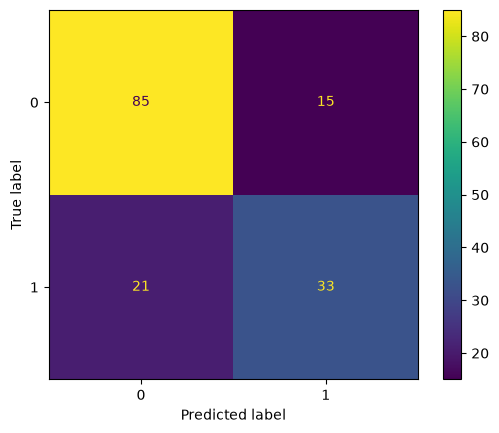

In [6]:
ConfusionMatrixDisplay(matrix).plot()

<Axes: >

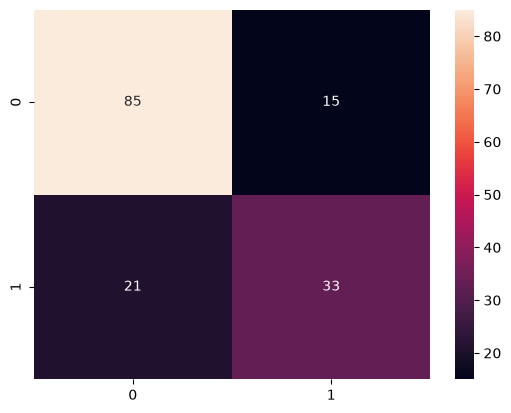

In [7]:
sns.heatmap(matrix, annot=True)

In [8]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.7662337662337663

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision score: ", precision_score(y_test, y_pred))
print("Recall score: ",recall_score(y_test, y_pred))
print("f1 score: ",f1_score(y_test, y_pred))

Precision score:  0.6875
Recall score:  0.6111111111111112
f1 score:  0.6470588235294118


In [12]:
from sklearn.metrics import precision_recall_curve
y_prob= log_reg.predict_proba(X_test)
p,r,t= precision_recall_curve(y_test, y_prob[:,0])



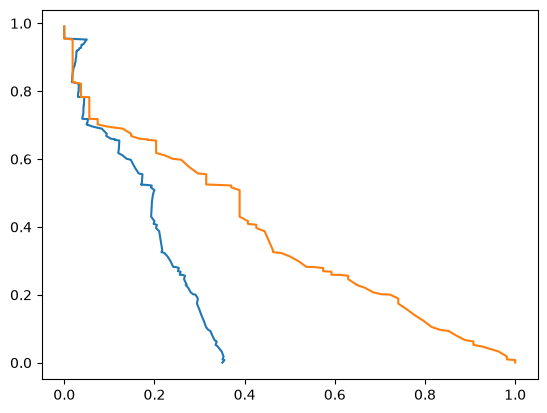

In [14]:
plt.plot(p[:-1], t)
plt.plot(r[:-1], t)

In [16]:
#Summary report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.83       100
           1       0.69      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154

